#**Breast Cancer analysis**

🧠 **Column Explanation (Simple)**

🧍‍♀️ **Personal Data**

**Age**
The patient’s age.

**Race**
Ethnicity (White / Black / Other).

**Marital Status**
Marital status (Married, Divorced, etc.).

🧬 **Cancer Stages**

**T Stage**
Size of the primary tumor (the higher the number → the larger the tumor).

**N Stage**
Whether the cancer has spread to lymph nodes and how many are affected.

**6th Stage**
Overall stage classification (like IIA, IIIB…).

**A Stage**
Simplified stage description (Local / Regional / Distant).

🔬 **Tumor Characteristics**

**Differentiate**
How differentiated the cells are (how close they look to normal cells):

* Well → Good (less dangerous)
* Moderately → متوسط (Moderate)
* Poorly → More dangerous

**Grade**
A number indicating cancer severity (1 = mild, 3 = severe).

**Tumor Size**
Size of the tumor (usually in millimeters).

🧪 **Hormonal Indicators**

**Estrogen Status**
Whether the tumor is sensitive to estrogen (positive / negative).

**Progesterone Status**
Whether it is sensitive to progesterone.

💡 These are important because they help determine the type of treatment.

🧠 **Lymph Nodes**

**Regional Node Examined**
Number of lymph nodes examined.

**Regional Node Positive**
Number of lymph nodes that actually contain cancer.

⏳ **Outcome**

**Survival Months**
Number of months the patient lived after diagnosis.

**Status**
Final condition:

* ALIVE → Alive
* DEAD → Deceased


I imported the essential libraries:

* pandas → for data processing
* numpy → for mathematical operations
* matplotlib & seaborn & plotly express → for visualization
* sklearn → for processing nan values


In [88]:
import numpy as np
import pandas as pd

Load data

In [89]:
from google.colab import files
uploaded = files.upload()


Saving Breast_Cancer_Uncleaned (1).csv to Breast_Cancer_Uncleaned (1) (1).csv


In [90]:
df = pd.read_csv('Breast_Cancer_Uncleaned (1).csv')

I started by understanding the structure of the data, the types of columns, and whether there are any missing values.


In [91]:
df

,Age,Race,Marital Status,T Stage,N Stage,6th Stage,differentiate,Grade,A Stage,Tumor Size,Estrogen Status,Progesterone Status,Regional Node Examined,Reginol Node Positive,Survival Months,Status
0,68,White,Married,T1,N1,iia,Poorly differentiated,3,REGIONAL,missing,positive,positive,24,1,MISSING,ALIVE
1,50,white,married,t2,N2,IIIA,Moderately differentiated,2,Regional,35,positive,Positive,14,NaN,62,ALIVE
2,58,white,Divorced,T3,N3,IIIC,Moderately differentiated,2,REGIONAL,63,Positive,NaN,14,NaN,75,alive
3,58,White,married,T1,N1,IIA,Poorly differentiated,NaN,Regional,18,positive,POSITIVE,2,1,84,Alive
4,47,WHITE,MARRIED,t2,N1,IIB,POORLY DIFFERENTIATED,3,regional,missing,Positive,POSITIVE,MISSING,1,50,alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62,other,married,T1,N1,IIA,Moderately differentiated,2,Regional,9,Positive,POSITIVE,1,1,49,alive
4020,56,white,DIVORCED,T2,n2,IIIA,Moderately differentiated,2,Regional,46,Positive,NaN,14,8,69,alive
4021,68,White,Married,T2,N1,IIB,Moderately differentiated,NaN,Regional,22,positive,negative,11,3,69,alive
4022,58,Black,Divorced,T2,N1,IIB,moderately differentiated,2,regional,44,Positive,Positive,11,1,missing,Alive


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Age                     3851 non-null   object
 1   Race                    3817 non-null   object
 2   Marital Status          3830 non-null   object
 3   T Stage                 3813 non-null   object
 4   N Stage                 3800 non-null   object
 5   6th Stage               3803 non-null   object
 6   differentiate           3811 non-null   object
 7   Grade                   3814 non-null   object
 8   A Stage                 3834 non-null   object
 9   Tumor Size              3818 non-null   object
 10  Estrogen Status         3831 non-null   object
 11  Progesterone Status     3805 non-null   object
 12  Regional Node Examined  3807 non-null   object
 13  Reginol Node Positive   3817 non-null   object
 14  Survival Months         3798 non-null   object
 15  Stat

I checked for missing values.


In [93]:
df.isnull().sum()

,0
Age,173
Race,207
Marital Status,194
T Stage,211
N Stage,224
6th Stage,221
differentiate,213
Grade,210
A Stage,190
Tumor Size,206


 Renaming column names


In [94]:

df.columns = df.columns.str.strip().str.replace(' ', '_').str.capitalize()

In [95]:
df.rename(columns={'6th_stage': 'Stage_6th'}, inplace=True)


Checking the values in each numeric column (since they appear as text columns) and fixing the issues.



In [96]:
df.Age.unique()

array(['68', '50', '58', '47', '51', '40', '69', 'MISSING', '65',
       ' missing ', '56', '43', '48', '57', '55', '62', '63', '46', '66',
       '53', '59', '60', '54', '49', '64', '42', '37', 'missing', '67',
       '31', '52', '33', nan, '45', '61', '39', '38', '36', '44', '41',
       '32', '34', ' MISSING ', '30', '35'], dtype=object)

In [97]:
df["Age"] = pd.to_numeric(df["Age"], errors='coerce')

In [98]:
df.Survival_months.unique()

array(['MISSING', '62', '75', '84', '50', '89', '54', '14', '70',
       ' missing ', '64', '92', '56', '38', '49', '105', '107', '77',
       'missing', '78', nan, '98', '102', '82', '86', '52', '90', '37',
       '103', ' MISSING ', '42', '63', '39', '59', '71', '74', '73', '91',
       '106', '60', '44', '85', '79', '104', '12', '95', '81', '55', '65',
       '72', '57', '40', '25', '8', '53', '58', '24', '66', '93', '94',
       '100', '87', '41', '67', '69', '101', '51', '13', '11', '47', '23',
       '45', '68', '15', '31', '76', '16', '99', '96', '7', '61', '48',
       '88', '97', '80', '83', '3', '22', '30', '6', '9', '5', '10', '19',
       '34', '18', '35', '27', '36', '4', '33', '26', '20', '28', '43',
       '17', '29', '21', '2', '46', '32'], dtype=object)

In [99]:
df["Survival_months"] = pd.to_numeric(df["Survival_months"], errors='coerce')

The **Grade** column, based on its name, appears to be numeric, but it is actually a categorical column. Therefore, it will remain as a text column, and the issues within it have been handled.


In [100]:
df.Grade.unique()

array(['3', '2', nan, ' 1 ', ' 3 ', ' 2 ', '1', ' anaplastic; grade iv ',
       'anaplastic; grade iv', ' anaplastic; Grade IV ',
       'anaplastic; Grade IV', ' ANAPLASTIC; GRADE IV '], dtype=object)

In [101]:
df['Grade'] = df['Grade'].str.lower().str.strip()

In [102]:
df.Grade.unique()

array(['3', '2', nan, '1', 'anaplastic; grade iv'], dtype=object)

In [103]:
df['Grade'] = df['Grade'].replace({
    'anaplastic; grade iv': '4'})

In [104]:
df.Grade.unique()

array(['3', '2', nan, '1', '4'], dtype=object)

Checking the values in each numeric column (since they appear as text columns) and fixing the issues.


In [105]:
df.Tumor_size.unique()

array(['missing', '35', '63', '18', '20', '8', '30', '103', '32', '13',
       '59', '15', '19', '46', ' MISSING ', '25', '29', '40', '70', '22',
       '17', '21', '10', '27', '23', '5', '51', nan, ' missing ', '55',
       '120', '77', '11', '12', '26', '75', '130', '34', '50', '80', '3',
       '60', '14', '24', '16', '45', '76', 'MISSING', '38', '49', '7',
       '4', '72', '9', '100', '43', '62', '37', '68', '52', '85', '57',
       '39', '28', '48', '110', '65', '105', '140', '31', '90', '2',
       '108', '98', '47', '42', '54', '61', '6', '36', '74', '33', '1',
       '81', '58', '117', '44', '123', '95', '107', '92', '69', '56',
       '82', '41', '78', '97', '88', '53', '101', '84', '83', '73', '66',
       '104', '94', '86', '64', '96', '79', '67'], dtype=object)

In [106]:
df["Tumor_size"] = pd.to_numeric(df["Tumor_size"], errors='coerce')

In [108]:
df.Regional_node_examined.unique()

array(['24', '14', '2', 'MISSING', '18', '11', '9', '20', '21', 'missing',
       '13', '23', '16', '22', ' missing ', '15', '4', '26', '31', '25',
       '10', '3', '5', '6', '19', '12', nan, '8', '17', '7', '49', '1',
       '33', '30', '34', '28', '32', '27', '42', '29', ' MISSING ', '41',
       '39', '40', '38', '47', '54', '36', '61', '37', '35', '43', '52',
       '45', '57', '51', '60'], dtype=object)

In [109]:
df["Regional_node_examined"] = pd.to_numeric(df["Regional_node_examined"], errors='coerce')

In [110]:
df.Reginol_node_positive.unique()

array(['1', nan, '2', 'MISSING', '18', '12', ' MISSING ', '3', '7', '14',
       ' missing ', 'missing', '22', '17', '23', '4', '6', '5', '9', '20',
       '16', '13', '11', '24', '10', '8', '27', '21', '26', '15', '19',
       '28', '31', '46', '33', '29', '37', '30', '35', '25', '32', '41',
       '34'], dtype=object)

In [111]:
df["Reginol_node_positive"] = pd.to_numeric(df["Reginol_node_positive"], errors='coerce')

To verify the cleaning and handling of the numeric columns.


In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4024 entries, 0 to 4023
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3449 non-null   float64
 1   Race                    3817 non-null   object 
 2   Marital_status          3830 non-null   object 
 3   T_stage                 3813 non-null   object 
 4   N_stage                 3800 non-null   object 
 5   Stage_6th               3803 non-null   object 
 6   Differentiate           3811 non-null   object 
 7   Grade                   3814 non-null   object 
 8   A_stage                 3834 non-null   object 
 9   Tumor_size              3432 non-null   float64
 10  Estrogen_status         3831 non-null   object 
 11  Progesterone_status     3805 non-null   object 
 12  Regional_node_examined  3421 non-null   float64
 13  Reginol_node_positive   3412 non-null   float64
 14  Survival_months         3399 non-null   

Checking the values inside each categorical (text) column due to different formatting styles, and then cleaning/standardizing them.


In [113]:
df.Race.unique()

array(['White', ' white ', 'WHITE', nan, 'white', ' WHITE ', ' Black ',
       ' other ', 'other', ' Other ', 'Other', 'black', ' White ',
       ' black ', ' OTHER ', 'Black', 'OTHER', ' BLACK ', 'BLACK'],
      dtype=object)

In [114]:
df.Marital_status.unique()

array(['Married', 'married', ' Divorced ', 'MARRIED', nan, 'widowed',
       ' MARRIED ', 'Divorced', ' married ', ' Single ', ' DIVORCED ',
       ' Married ', ' SINGLE ', 'DIVORCED', 'separated', 'single',
       'Widowed', 'Single', ' Widowed ', ' single ', 'SINGLE',
       ' WIDOWED ', 'divorced', 'WIDOWED', ' divorced ', 'SEPARATED',
       ' separated ', ' widowed ', 'Separated', ' Separated ',
       ' SEPARATED '], dtype=object)

In [115]:
df.T_stage.unique()

array(['T1', 't2', 'T3', ' t2 ', 't1', nan, ' T4 ', ' t1 ', 'T2', ' T1 ',
       ' T3 ', ' T2 ', 't3', 't4', ' t3 ', 'T4', ' t4 '], dtype=object)

In [116]:
df.A_stage.unique()

array([' REGIONAL ', 'Regional', 'REGIONAL', ' regional ', ' Regional ',
       'Distant', 'regional', nan, 'distant', ' distant ', ' DISTANT ',
       'DISTANT', ' Distant '], dtype=object)

In [117]:
df.N_stage.unique()

array(['N1', 'N2', ' N3 ', ' N1 ', ' n1 ', nan, 'N3', 'n1', ' n3 ', 'n3',
       'n2', ' N2 ', ' n2 '], dtype=object)

In [118]:
df.Stage_6th.unique()

array(['iia', 'IIIA', ' IIIC ', ' IIA ', 'IIB', 'IIA', nan, 'IIIC',
       'iiia', ' iib ', 'iib', 'iiic', ' IIIA ', ' iiic ', ' IIB ',
       ' iiia ', ' iia ', ' IIIB ', 'IIIB', 'iiib', ' iiib '],
      dtype=object)

In [119]:
df.Differentiate.unique()

array(['Poorly differentiated', ' Moderately differentiated ',
       'Moderately differentiated', 'POORLY DIFFERENTIATED', nan,
       'well differentiated', 'Well differentiated',
       ' MODERATELY DIFFERENTIATED ', ' poorly differentiated ',
       'moderately differentiated', 'MODERATELY DIFFERENTIATED',
       ' Poorly differentiated ', ' moderately differentiated ',
       ' POORLY DIFFERENTIATED ', ' WELL DIFFERENTIATED ',
       'poorly differentiated', ' well differentiated ',
       'WELL DIFFERENTIATED', ' Well differentiated ', 'undifferentiated',
       ' undifferentiated ', ' Undifferentiated ', 'Undifferentiated',
       ' UNDIFFERENTIATED ', 'UNDIFFERENTIATED'], dtype=object)

In [120]:
df.Estrogen_status.unique()

array([' positive ', ' Positive ', 'positive', 'Positive', 'POSITIVE',
       ' POSITIVE ', 'negative', 'Negative', nan, ' NEGATIVE ',
       'NEGATIVE', ' Negative ', ' negative '], dtype=object)

In [121]:
df.Progesterone_status.unique()

array([' positive ', ' Positive ', nan, 'POSITIVE', ' POSITIVE ',
       'positive', 'Positive', ' Negative ', 'Negative', 'negative',
       ' NEGATIVE ', ' negative ', 'NEGATIVE'], dtype=object)

In [122]:
df.Status.unique()

array(['ALIVE', ' alive ', ' Alive ', 'alive', ' ALIVE ', 'Alive',
       ' Dead ', 'DEAD', nan, ' dead ', 'Dead', 'dead', ' DEAD '],
      dtype=object)

In [123]:
# الأعمدة النصية التي تحتاج إلى التعديل
categorical_columns = ['Race','Marital_status','T_stage','N_stage','Differentiate','A_stage','Estrogen_status','Progesterone_status','Status']  # استبدل بأسماء الأعمدة لديك

# تطبيق التعديل على كل الأعمدة النصية
for col in categorical_columns:
    df[col] = df[col].str.strip().str.lower().str.title()


In [124]:
df['Stage_6th'] = df['Stage_6th'].str.strip().str.upper()

In [125]:
df

,Age,Race,Marital_status,T_stage,N_stage,Stage_6th,Differentiate,Grade,A_stage,Tumor_size,Estrogen_status,Progesterone_status,Regional_node_examined,Reginol_node_positive,Survival_months,Status
0,68.0,White,Married,T1,N1,IIA,Poorly Differentiated,3,Regional,NaN,Positive,Positive,24.0,1.0,NaN,Alive
1,50.0,White,Married,T2,N2,IIIA,Moderately Differentiated,2,Regional,35.0,Positive,Positive,14.0,NaN,62.0,Alive
2,58.0,White,Divorced,T3,N3,IIIC,Moderately Differentiated,2,Regional,63.0,Positive,NaN,14.0,NaN,75.0,Alive
3,58.0,White,Married,T1,N1,IIA,Poorly Differentiated,NaN,Regional,18.0,Positive,Positive,2.0,1.0,84.0,Alive
4,47.0,White,Married,T2,N1,IIB,Poorly Differentiated,3,Regional,NaN,Positive,Positive,NaN,1.0,50.0,Alive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4019,62.0,Other,Married,T1,N1,IIA,Moderately Differentiated,2,Regional,9.0,Positive,Positive,1.0,1.0,49.0,Alive
4020,56.0,White,Divorced,T2,N2,IIIA,Moderately Differentiated,2,Regional,46.0,Positive,NaN,14.0,8.0,69.0,Alive
4021,68.0,White,Married,T2,N1,IIB,Moderately Differentiated,NaN,Regional,22.0,Positive,Negative,11.0,3.0,69.0,Alive
4022,58.0,Black,Divorced,T2,N1,IIB,Moderately Differentiated,2,Regional,44.0,Positive,Positive,11.0,1.0,NaN,Alive


Handling NaN values in categorical (text) columns.


In [126]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='constant', fill_value='Unknown')
df[['Race','Marital_status','T_stage','N_stage','Stage_6th','Differentiate','A_stage','Estrogen_status','Progesterone_status','Status','Grade']] = imputer.fit_transform(df[['Race','Marital_status','T_stage','N_stage','Stage_6th','Differentiate','A_stage','Estrogen_status','Progesterone_status','Status','Grade']])


Handling NaN values in numerical columns using the median, taking into account the presence of outliers.



In [127]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
df[['Age','Tumor_size','Regional_node_examined','Reginol_node_positive','Survival_months']] = imputer.fit_transform(df[['Age','Tumor_size','Regional_node_examined','Reginol_node_positive','Survival_months']])

To verify that there are no remaining NaN values.


In [128]:
df.isnull().sum()

,0
Age,0
Race,0
Marital_status,0
T_stage,0
N_stage,0
Stage_6th,0
Differentiate,0
Grade,0
A_stage,0
Tumor_size,0


Understanding the distribution of values in the numerical columns, checking whether there is any skewness in each column, and using boxplots to detect outliers for every column along with some basic statistical summaries.


In [129]:
df.Age.skew()

np.float64(-0.2251088177264451)

<Axes: >

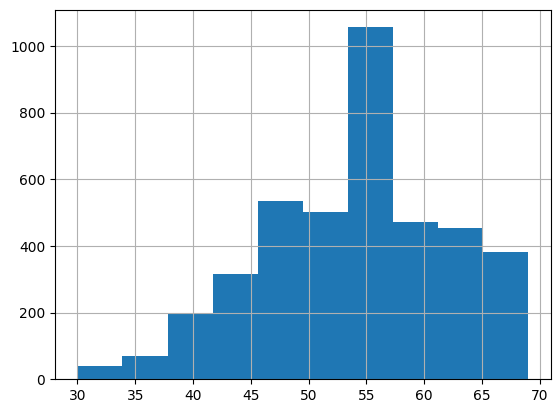

In [130]:
df.Age.hist()

In [131]:
print(df['Age'].describe())


count    4024.000000
mean       53.939861
std         8.222385
min        30.000000
25%        48.000000
50%        54.000000
75%        60.000000
max        69.000000
Name: Age, dtype: float64


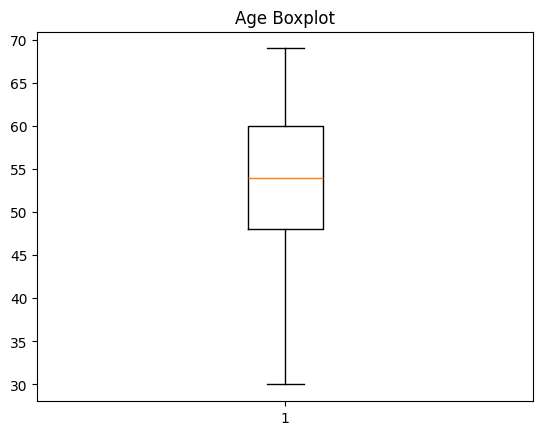

In [132]:
import matplotlib.pyplot as plt

plt.boxplot(df['Age'])
plt.title("Age Boxplot")
plt.show()

Left-skewed distribution and no outliers in the age column.


In [133]:
df.Tumor_size.skew()

np.float64(1.9762109072484648)

<Axes: >

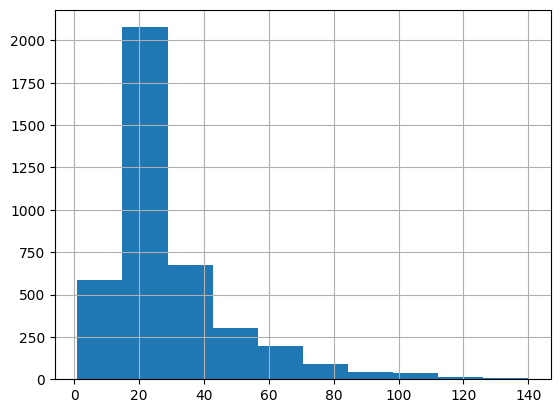

In [134]:
df.Tumor_size.hist()

In [135]:
print(df['Tumor_size'].describe())

count    4024.000000
mean       29.594185
std        19.521343
min         1.000000
25%        18.000000
50%        25.000000
75%        35.000000
max       140.000000
Name: Tumor_size, dtype: float64


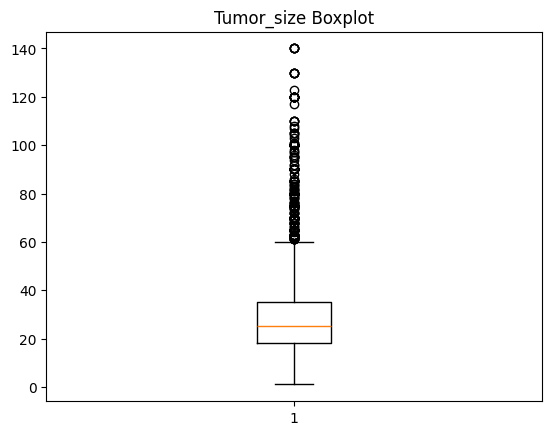

In [136]:
import matplotlib.pyplot as plt

plt.boxplot(df['Tumor_size'])
plt.title("Tumor_size Boxplot")
plt.show()

Right-skewed distribution with outliers present in the tumor size column.


In [137]:
df.Regional_node_examined.skew()

np.float64(0.9471797052710587)

<Axes: >

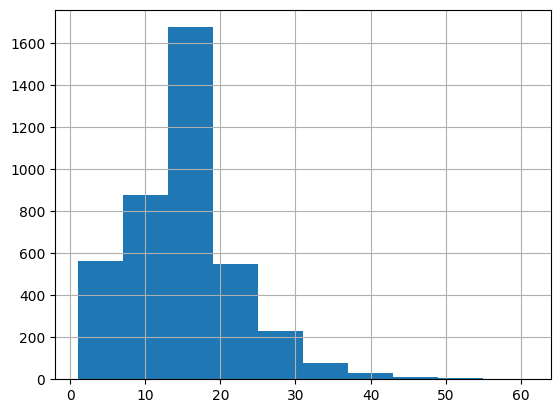

In [138]:
df.Regional_node_examined.hist()

In [139]:
print(df['Regional_node_examined'].describe())

count    4024.000000
mean       14.385437
std         7.489444
min         1.000000
25%        10.000000
50%        14.000000
75%        18.000000
max        61.000000
Name: Regional_node_examined, dtype: float64


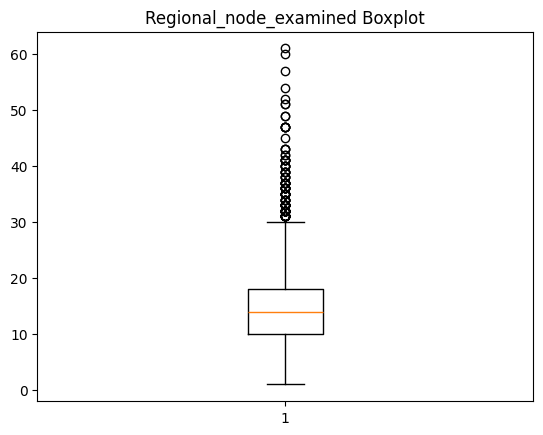

In [140]:
import matplotlib.pyplot as plt

plt.boxplot(df['Regional_node_examined'])
plt.title("Regional_node_examined Boxplot")
plt.show()

Right-skewed distribution with outliers present in the Regional_node_examined column.


In [141]:
df.Reginol_node_positive.skew()

np.float64(3.0036993932230462)

<Axes: >

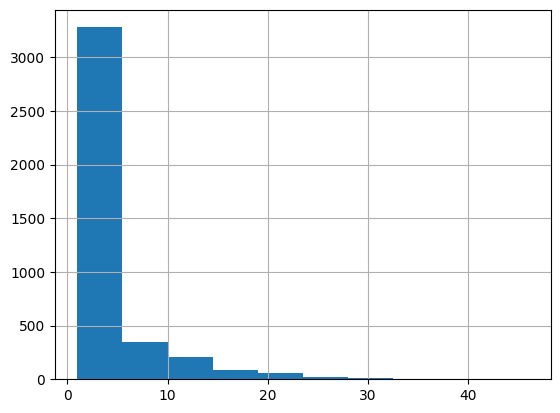

In [142]:
df.Reginol_node_positive.hist()

In [143]:
print(df['Reginol_node_positive'].describe())

count    4024.000000
mean        3.838966
std         4.770801
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max        46.000000
Name: Reginol_node_positive, dtype: float64


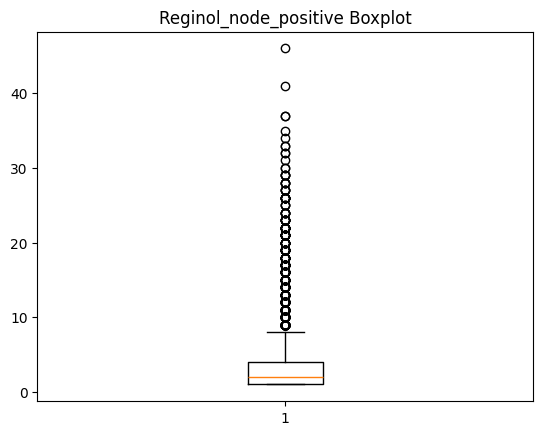

In [144]:
import matplotlib.pyplot as plt

plt.boxplot(df['Reginol_node_positive'])
plt.title("Reginol_node_positive Boxplot")
plt.show()

Right-skewed distribution with outliers present in the Reginol_node_positive column.


In [145]:
df.Survival_months.skew()

np.float64(-0.6890676628408615)

<Axes: >

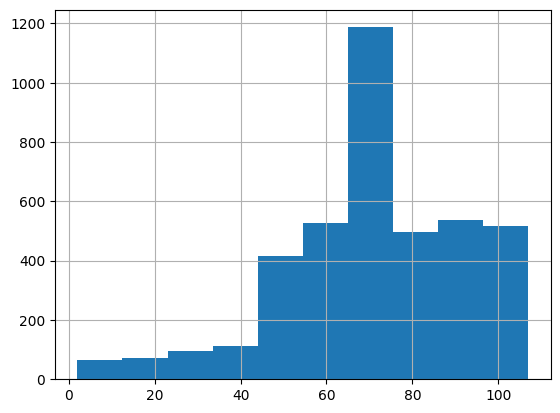

In [146]:
df.Survival_months.hist()

In [147]:
print(df['Survival_months'].describe())

count    4024.000000
mean       71.449801
std        21.096831
min         2.000000
25%        59.000000
50%        73.000000
75%        86.000000
max       107.000000
Name: Survival_months, dtype: float64


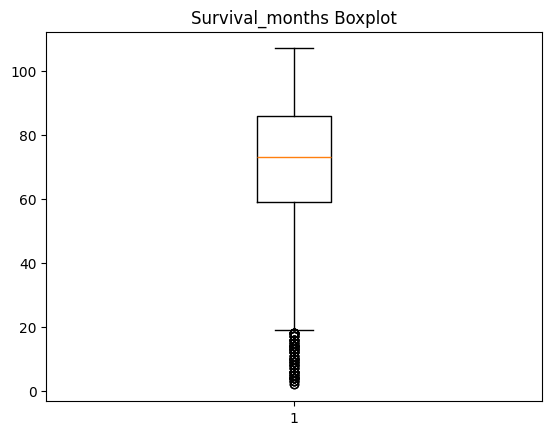

In [148]:
import matplotlib.pyplot as plt

plt.boxplot(df['Survival_months'])
plt.title("Survival_months Boxplot")
plt.show()

Left-skewed distribution and  outliers in the survial month column.


#

Identifying the outlier values within each column.


In [149]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary[col] = len(outliers)

# عرض النتيجة
for col, count in outlier_summary.items():
    print(f"{col}: {count} outliers")

Age: 0 outliers
Tumor_size: 298 outliers
Regional_node_examined: 124 outliers
Reginol_node_positive: 473 outliers
Survival_months: 108 outliers


Handling outliers in each column using clipping.


In [150]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)

Detecting duplicate records.


In [151]:
print(df.duplicated().sum())

1


Handling duplicate records (removing duplicates).


In [152]:
df.drop_duplicates(inplace=True)


Verifying that duplicate records have been successfully handled.


In [153]:
print(df.duplicated().sum())

0


Checking the values in each column and their frequency (value counts).


In [154]:
for col in df.columns:
    print(f"====== {col} ======")
    print(df[col].value_counts())
    print("\n")


====== Age ======
Age
54.0    690
47.0    139
51.0    137
49.0    136
53.0    136
46.0    133
63.0    132
55.0    131
59.0    129
61.0    127
57.0    126
48.0    126
50.0    126
62.0    123
60.0    114
56.0    108
67.0    104
52.0    104
65.0    103
58.0    101
66.0    101
64.0     96
68.0     91
45.0     88
69.0     87
43.0     84
42.0     72
44.0     71
40.0     64
41.0     58
39.0     43
38.0     35
37.0     26
36.0     21
31.0     13
34.0     12
33.0     11
32.0     10
35.0     10
30.0      5
Name: count, dtype: int64


====== Race ======
Race
White      3240
Other       302
Black       274
Unknown     207
Name: count, dtype: int64


====== Marital_status ======
Marital_status
Married      2503
Single        591
Divorced      464
Widowed       228
Unknown       194
Separated      43
Name: count, dtype: int64


====== T_stage ======
T_stage
T2         1702
T1         1515
T3          500
Unknown     211
T4           95
Name: count, dtype: int64


====== N_stage ======
N_stage
N1    

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Is age associated with the number of survival months?


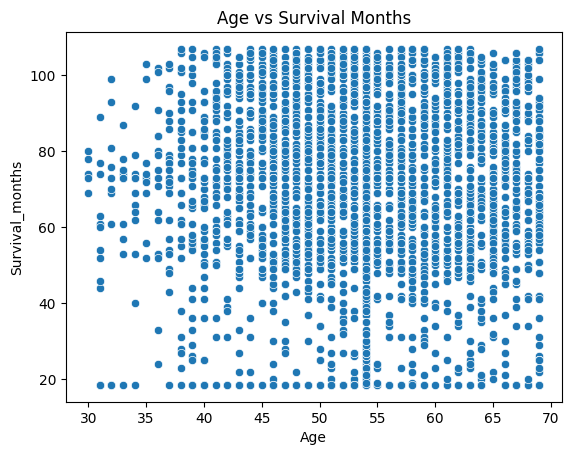

In [155]:
sns.scatterplot(x='Age', y='Survival_months', data=df)
plt.title('Age vs Survival Months')

plt.show()

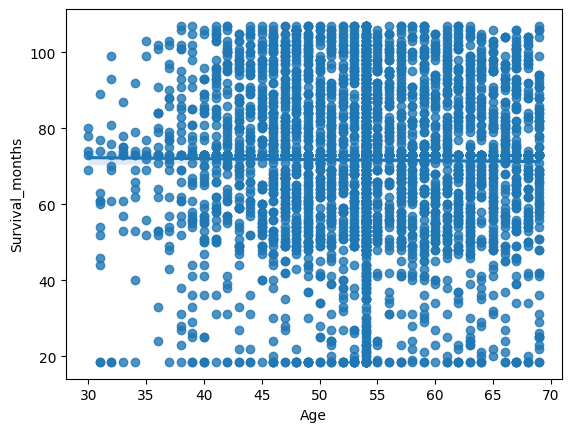

In [156]:
sns.regplot(x='Age', y='Survival_months', data=df)
plt.show()


In [157]:
print(df['Age'].corr(df['Survival_months']))

-0.010842598609038774


There is no statistically significant relationship between patient age and survival months in this dataset. Age alone is not a reliable predictor of survival outcomes.


#

Does marital status affect the number of survival months in breast cancer patients?


In [158]:
martial_survail_months = df.groupby('Marital_status',as_index=False)['Survival_months'].mean()


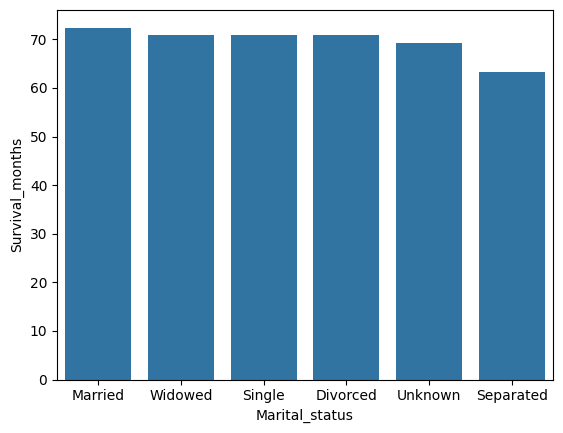

In [159]:
sns.barplot(x='Marital_status', y='Survival_months', data=martial_survail_months.sort_values(by='Survival_months',ascending=False))
plt.show()

Conclusion: Marital status may play a role in providing psychological and social support to the patient, which can improve survival outcomes, especially for married patients who often receive stronger family support.


#

What is the distribution of breast cancer patients based on final health status (Alive / Dead / Unknown)?


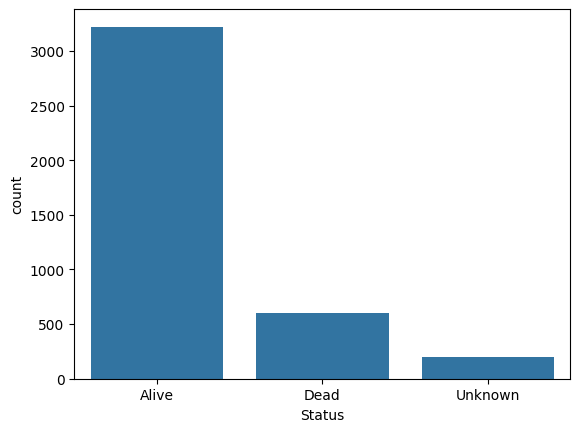

In [160]:
sns.countplot(x='Status', data=df)
plt.show()

Conclusion: The survival rate is very high, exceeding 80%, which may reflect the effectiveness of early treatment or indicate that the dataset mainly represents early-stage cases. Overall, this is a positive indicator.


#

Is there a relationship between tumor size and survival months?


In [161]:
import plotly.express as px

In [162]:
px.scatter(df, x='Tumor_size', y='Survival_months', color='Status',trendline='ols')

In [163]:
print(df['Tumor_size'].corr(df['Survival_months']))

-0.07948952347989707


Conclusion:

Although there is a logical expectation of an inverse relationship, the weak correlation suggests that tumor size alone does not determine the patient’s survival outcome. This highlights the importance of using multivariate analysis in this project.


#

Do breast cancer clinical stages (T_stage) differ in average tumor size? And is there a logical relationship between stage and tumor size?

In [164]:
tstage_tumorsize_mean = df.groupby('T_stage')['Tumor_size'].mean()

In [165]:
tstage_tumorsize_mean = tstage_tumorsize_mean.sort_values(ascending=False)

In [166]:
tstage_tumorsize_mean

,Tumor_size
T_stage,
T3,53.233000
T4,42.431579
T2,30.446533
Unknown,28.741706
T1,15.868647


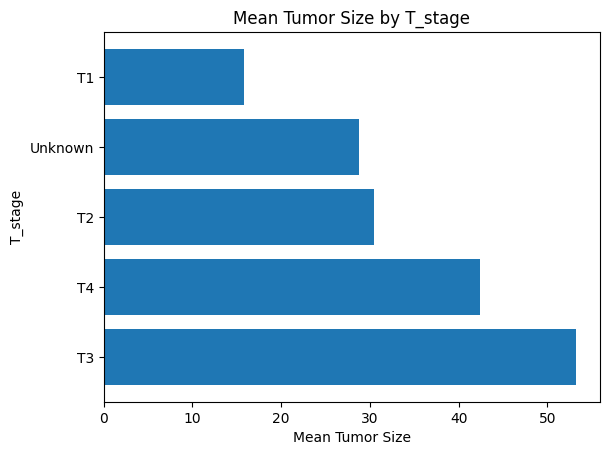

In [167]:
plt.barh(tstage_tumorsize_mean.index,tstage_tumorsize_mean.values)
plt.xlabel('Mean Tumor Size')
plt.ylabel('T_stage')
plt.title('Mean Tumor Size by T_stage')
plt.show()

Conclusion:
There is a clear positive relationship between clinical stage and tumor size, confirming that T_stage classification reflects the actual progression of the disease. This supports the validity and reliability of the dataset.


#

Do breast cancer Grade differ in average tumor size? And is there a logical relationship between Grade and tumor size?

In [168]:
grade_tumorsize_mean = df.groupby('Grade', as_index=False)['Tumor_size'].mean()

In [169]:
px.bar(grade_tumorsize_mean.sort_values(by ='Tumor_size'), x='Grade', y='Tumor_size')


Conclusion: There is a clear positive relationship between Grade and tumor size, confirming that Grade classification reflects the actual progression of the disease. This supports the validity and reliability of the dataset.

#

Is there a relationship between the number of positive lymph nodes (Reginol_node_positive) and tumor size?

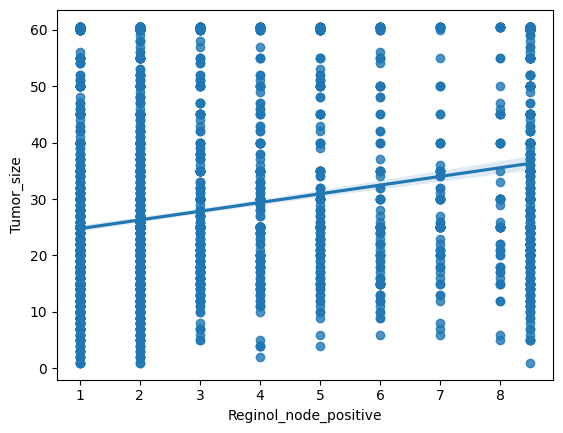

In [170]:
sns.regplot(x='Reginol_node_positive', y='Tumor_size', data=df)
plt.show()

In [171]:
print(df['Reginol_node_positive'].corr(df['Tumor_size']))

0.2624643395858119


Conclusion:
Lymph node involvement is associated with tumor size, meaning that larger tumors are more likely to spread to lymph nodes. This is an important indicator of disease severity and progression.


#

Does the average tumor size differ between patients who died and those who are still alive?

In [172]:
status_tumorsize_mean = df.groupby('Status', as_index=False)['Tumor_size'].mean()

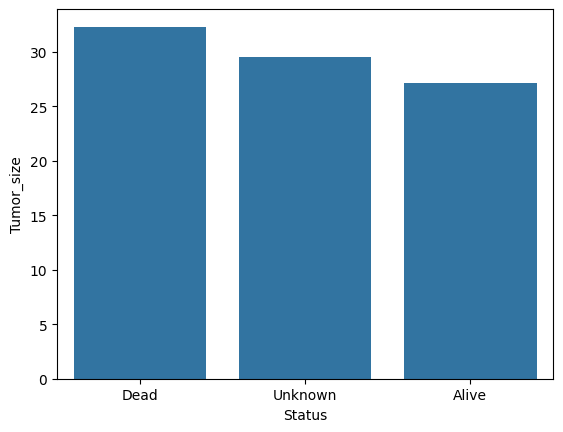

In [173]:
sns.barplot(x='Status', y='Tumor_size', data=status_tumorsize_mean.sort_values(by='Tumor_size',ascending=False))
plt.show()

Patients who died had a larger average tumor size compared to those who are still alive. This supports the idea that tumor size is a risk factor affecting survival outcomes

#

What are the strongest relationships between the numerical variables in the dataset?

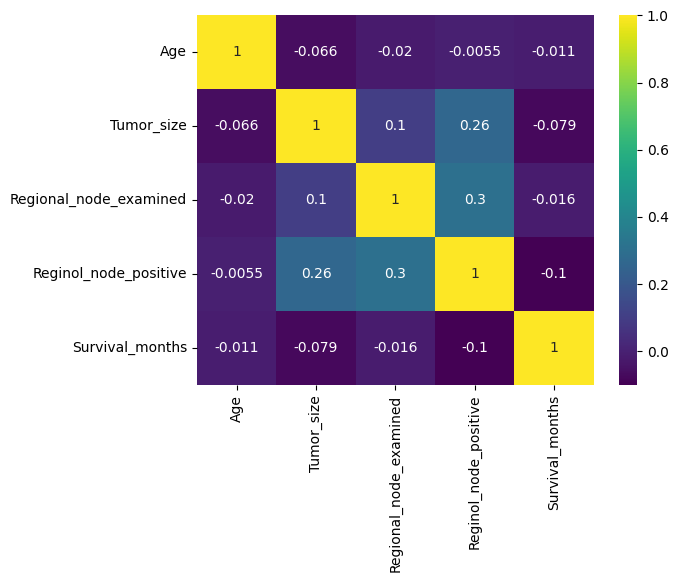

In [174]:
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='viridis')
plt.show()

Final conclusion:
The strongest relationship is between the examined lymph nodes and the positive lymph nodes, which is expected from a medical perspective. On the other hand, Survival_months does not show a strong correlation with any single variable. This confirms that survival is a multifactorial outcome that depends on several interacting factors, and therefore requires more advanced predictive models rather than relying on single-variable analysis.
